**<h1>AHJ Database: California Built Environment Personnel Mapping 2025**
#### Analysis 2.v4 =  Analysis 2 (filtered GCC data) + Geomap
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 06/25/2025</i>
* AHJ Data: City and County level data sourced from Government Compensation California (GCC)
* Geo Data: Various open source databases including state and federal - ranging from census, ArcGIS, and other open sources
* Started development on 06/25/2025
* Finished Iteration on -06/25/2025-

In [122]:
# Run once for pip installs and upgrades
#%pip install --upgrade pip


In [123]:
# Import and load libs and packages
import pandas as pd
import re
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from rapidfuzz import process, fuzz

# Download NLTK stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rford\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [124]:
# Load base dataset here
df = pd.read_excel("2023_City.xlsx")

# Split into training (30%) and test (70%)
train_df = df.sample(frac=0.3, random_state=42)
test_df = df.drop(train_df.index)

In [125]:
# Keywords to KEEP
keep_dept_keywords = [
    "Planning", "Community Development", "Building Department", "Code Compliance",
    "Public Works", "Streets", "Engineering", "Construction", "Zoning"
]

keep_position_keywords = [
    "Construction", "Building", "HVAC", "Plans Inspector", "Zoning Investigator",
    "Architect", "Permit Technician", "Safety Inspector", "Planner", "Code Enforcer",
    "Plan Check Coordinator", "Licensing Specialist", "Community Development Technician"
]

# Keywords to FILTER OUT
filter_dept_keywords = [
    "Administration", "Communications", "Animal", "Finance", "Community Services",
    "Municipal Power", "Base Reuse", "City Attorney", "City Clerk", "Council", "Fire",
    "Human Resources", "Library", "IT", "Police", "Recreation", "Government Services",
    "Facilities", "Water", "Power", "Airport", "Health", "Zero Waste", "Sewer",
    "Equipment", "Transfer Station", "Janitor", "Landscaping", "Utilities", "Business",
    "Transit", "Nutrition", "Aging", "Adult", "Youth", "Homeless", "Athletics", "Law",
    "Attorney", "Management","Public Works - Sanitation","Public Works - Street Services",
    "Public Works - Maint Svcs","Streets","Public Works-Operations","Public Works - Parks And Landscape ",
    "Public Works - Streets","Public Works-Corporate Yard","Public Works - Maintenance",
    "Public Works - Parks","Public Works Operations","Public Works - Refuse","Public Works/Solid Waste",
    "Public Works - Solid Waste","Public Works - Wastewater","Public Works/Street Maintenance",
    "War Memorial","Public Works - Right Of Way","Public Works - Utility Services", "Street Maintenance",
    "Public Works Parks","Grounds Maintenance","Public Works Yard",
    
]

filter_position_keywords = [
    "Motor Sweeper Operator","Public Works Ranger","Park Ranger","Administrative Assistant","Fitness instructor",
    "Administrative Intern","Equipment Operator","Crossing Guard","Park Lead","Plumber","Mechanic","Gardener",
    "Temporary","Chemist","Seasonal Aide","Plant Operator","Solid Resources","Parks","Asphalt Worker",
    "Business Analyst","Human Resources","Parking","Facilities","Golf","Downtown","Stationary","Groundskeeper"
    "Laboratory Technician", "Building & Grounds Patrol Officer", "Patrol Officer", "Youth Job Corps Program Participant",
    "School Guard","Tree Trimmer", "Transit Coach Operator", "Street Inspector","Utility Worker","Custodial",
    "Office Specialist","Street Services","Maintenance","Accountant","City Worker","Sanitation","Graffiti"
    "Maintenance Supervisor","Wastewater Treatment Operator","Wastewater Treatment Mechanic","Office Assistant",
    "Recreational Leader", "Librarian", "Admin", "Clerk","Wastewater System Operator","Water Foreman",
    "Wastewater Conveyance Operator","Management Assistant","Street Maintenance Worker","Maintenance Aide",
    "Lot Operator","Public Works Maintenance Worker","Maintenance Worker","Project Assistant","Project Manager",
    "Tree Surgeon","Intern","Truck Driver","Solid Waste Equipment Operator","Refuse Operator","Refuse Collection Supervisor",
    "Secretary", "Parking Officer", "Police", "Firefighter", "Treasurer", "Employment Worker",
    "Lifeguard", "Animal", "Recycling","Management Analyst", "Sewer", "Finance", "HR", "IT", "Parks & Rec",
    "Health", "EMT", "Custodian","Maintenance Worker", "Equipment Mechanic", "Aquatics", "Traffic",
    "Community Service", "Veterinary", "Senior Citizen", "Pool", "Utilities", "Audio","Irrigation Specialist",
    "Communications", "Mayor", "Attendant", "Vocational Worker", "Messenger Clerk","Staff Assistant",
    "Customer Service", "Truck Operator", "Sanitation", "Painter","Water Utility Worker","Arborist"
    "Laborer", "Program Assistant","Staff Specialist","Refuse","Department Assistant","Landscape"
]


In [126]:
# Helper function to match keywords
def keyword_match(text, keywords):
    if pd.isna(text):
        return False
    return any(re.search(rf'\b{re.escape(k)}\b', str(text), re.IGNORECASE) for k in keywords)

# Label rows for training
def label_row(row):
    keep_dept = keyword_match(row['DepartmentOrSubdivision'], keep_dept_keywords)
    keep_pos = keyword_match(row['Position'], keep_position_keywords)
    filter_dept = keyword_match(row['DepartmentOrSubdivision'], filter_dept_keywords)
    filter_pos = keyword_match(row['Position'], filter_position_keywords)
    return int((keep_dept or keep_pos) and not (filter_dept or filter_pos))


In [127]:
# Apply labeling
train_df["label"] = train_df.apply(label_row, axis=1)

# Combine text for model training
train_df["combined_text"] = train_df["DepartmentOrSubdivision"].fillna('') + " " + train_df["Position"].fillna('')

# Show label distribution
train_df["label"].value_counts()


label
0    96444
1     6866
Name: count, dtype: int64

In [128]:
# Feature and Target Preparation

X = train_df["combined_text"]
y = train_df["label"]


In [129]:
# Create pipeline with TF-IDF + Logistic Regression
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=stopwords.words('english'), max_features=1000)),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
# Train model
model.fit(X, y)


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [130]:
# Combine text columns
test_df["combined_text"] = test_df["DepartmentOrSubdivision"].fillna('') + " " + test_df["Position"].fillna('')

# Predict using the trained model
test_df["predicted_label"] = model.predict(test_df["combined_text"])

# Filter the results
filtered_df = test_df[test_df["predicted_label"] == 1]

# Display summary
print(f"Filtered rows: {len(filtered_df)} / {len(test_df)}")
filtered_df.head()


Filtered rows: 15910 / 241056


,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,MaxPositionSalary,...,PensionFormula,EmployerURL,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType,combined_text,predicted_label
58,2023,City,Agoura Hills,Community Development,Associate Planner,False,False,NaN,98041.0,119454.0,...,2%@55,https://www.agourahillscity.org/department/hum...,19841,2024-06-25,Los Angeles,NaN,False,NaN,Community Development Associate Planner,1
59,2023,City,Agoura Hills,Community Development,Associate Planner,False,False,NaN,98041.0,119454.0,...,2%@62,https://www.agourahillscity.org/department/hum...,19841,2024-06-25,Los Angeles,NaN,False,NaN,Community Development Associate Planner,1
60,2023,City,Agoura Hills,Community Development,Building Official,False,False,NaN,141993.0,173005.0,...,2%@62,https://www.agourahillscity.org/department/hum...,19841,2024-06-25,Los Angeles,NaN,False,NaN,Community Development Building Official,1
61,2023,City,Agoura Hills,Community Development,Community Development Director,False,False,NaN,173005.0,210789.0,...,2%@62,https://www.agourahillscity.org/department/hum...,19841,2024-06-25,Los Angeles,NaN,False,NaN,Community Development Community Development Di...,1
62,2023,City,Agoura Hills,Community Development,Land Use Technician,False,False,NaN,78504.0,95650.0,...,2%@55,https://www.agourahillscity.org/department/hum...,19841,2024-06-25,Los Angeles,NaN,False,NaN,Community Development Land Use Technician,1


In [131]:
# Visual Checks of headers for personnel data and geodata 
#print(ca_personnel.head())
#print(ca_personnel.columns)


In [132]:
# Cleaning function
def clean_name(name):
    name = str(name).strip().lower()
    return name.title() if name else ''

# Clean columns for joining
filtered_df['clean_city_name'] = filtered_df['EmployerName'].apply(clean_name)
filtered_df['clean_county_name'] = filtered_df['EmployerCounty'].apply(clean_name)


C:\Users\Rford\AppData\Local\Temp\ipykernel_2900\2798458203.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['clean_city_name'] = filtered_df['EmployerName'].apply(clean_name)
C:\Users\Rford\AppData\Local\Temp\ipykernel_2900\2798458203.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['clean_county_name'] = filtered_df['EmployerCounty'].apply(clean_name)


In [133]:
# Filters: Empty if not needed

# Specify the city to exclude
excluded_cities = ["Los Angeles"]
# Specify the county to exclude
excluded_counties = ["Los Angeles"]


In [134]:
# Aggregate and filter 
agg_city_counts = filtered_df.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts = filtered_df.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

filtered_city = filtered_df[~filtered_df['clean_city_name'].isin(excluded_cities)]
filtered_county = filtered_df[~filtered_df['clean_county_name'].isin(excluded_counties)]

agg_city_counts_filtered = filtered_city.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts_filtered = filtered_county.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

# Check the aggregated personnel count for cities and counties
#agg_city_counts
#agg_city_counts_filtered
#agg_county_counts
#agg_county_counts_filtered
#filtered_city
#filtered_county



In [135]:
# Bin ranges
agg_city_counts['city_personnel_bin'] = pd.cut(
    agg_city_counts['personnel_count_city'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)

agg_county_counts['county_personnel_bin'] = pd.cut(
    agg_county_counts['personnel_count_county'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)


In [136]:
# Read Files and load data
ca_geo_df = gpd.read_file("City_and_County_Boundary_Line_Changes_-3971126187329447856/BOE_CityCounty.shp")
county_geo = gpd.read_file("California_County_Boundaries_and_Identifiers_Blue_Version_view_2716745428963682036/California_County_Boundaries_and_Identifiers.shp")


In [137]:
# City maps (full + filtered)
geo_city = ca_geo_df.copy()
geo_city['clean_name'] = geo_city['CITY'].apply(clean_name)
geo_city = geo_city.merge(
    agg_city_counts[['clean_city_name', 'personnel_count_city', 'city_personnel_bin']],
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

geo_city['personnel_count_city'] = geo_city['personnel_count_city'].fillna(0)

# Merge all needed data
geo_city_filtered = ca_geo_df.copy()
geo_city_filtered['clean_name'] = geo_city_filtered['CITY'].apply(clean_name)

geo_city_filtered = geo_city_filtered.merge(
    agg_city_counts_filtered,
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

# Fill missing values for plotting
geo_city_filtered['personnel_count_city'] = geo_city_filtered['personnel_count_city'].fillna(0)



In [138]:
# Merge with county_geo: Full
county_geo['clean_name'] = county_geo['CDT_NAME_S'].apply(clean_name)

geo_county = county_geo.merge(
    agg_county_counts[['clean_county_name', 'personnel_count_county', 'county_personnel_bin']],
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)
geo_county['personnel_count_county'] = geo_county['personnel_count_county'].fillna(0)

# Merge with county_geo: Filtered
geo_county_filtered = county_geo.merge(
    agg_county_counts_filtered,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)

# Fill missing personnel counts with 0
geo_county_filtered['personnel_count_county'] = geo_county_filtered['personnel_count_county'].fillna(0)

In [139]:
# Checks for geomaps
#geo_city
#geo_city_filtered
#geo_county
#geo_county_filtered

In [140]:
# Defining plotting function

def plot_personnel_map(gdf, column, title, cmap='YlGnBu'):
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing data"}
    )
    legend = ax.get_legend()
    if legend:
        legend.set_title(title)

    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


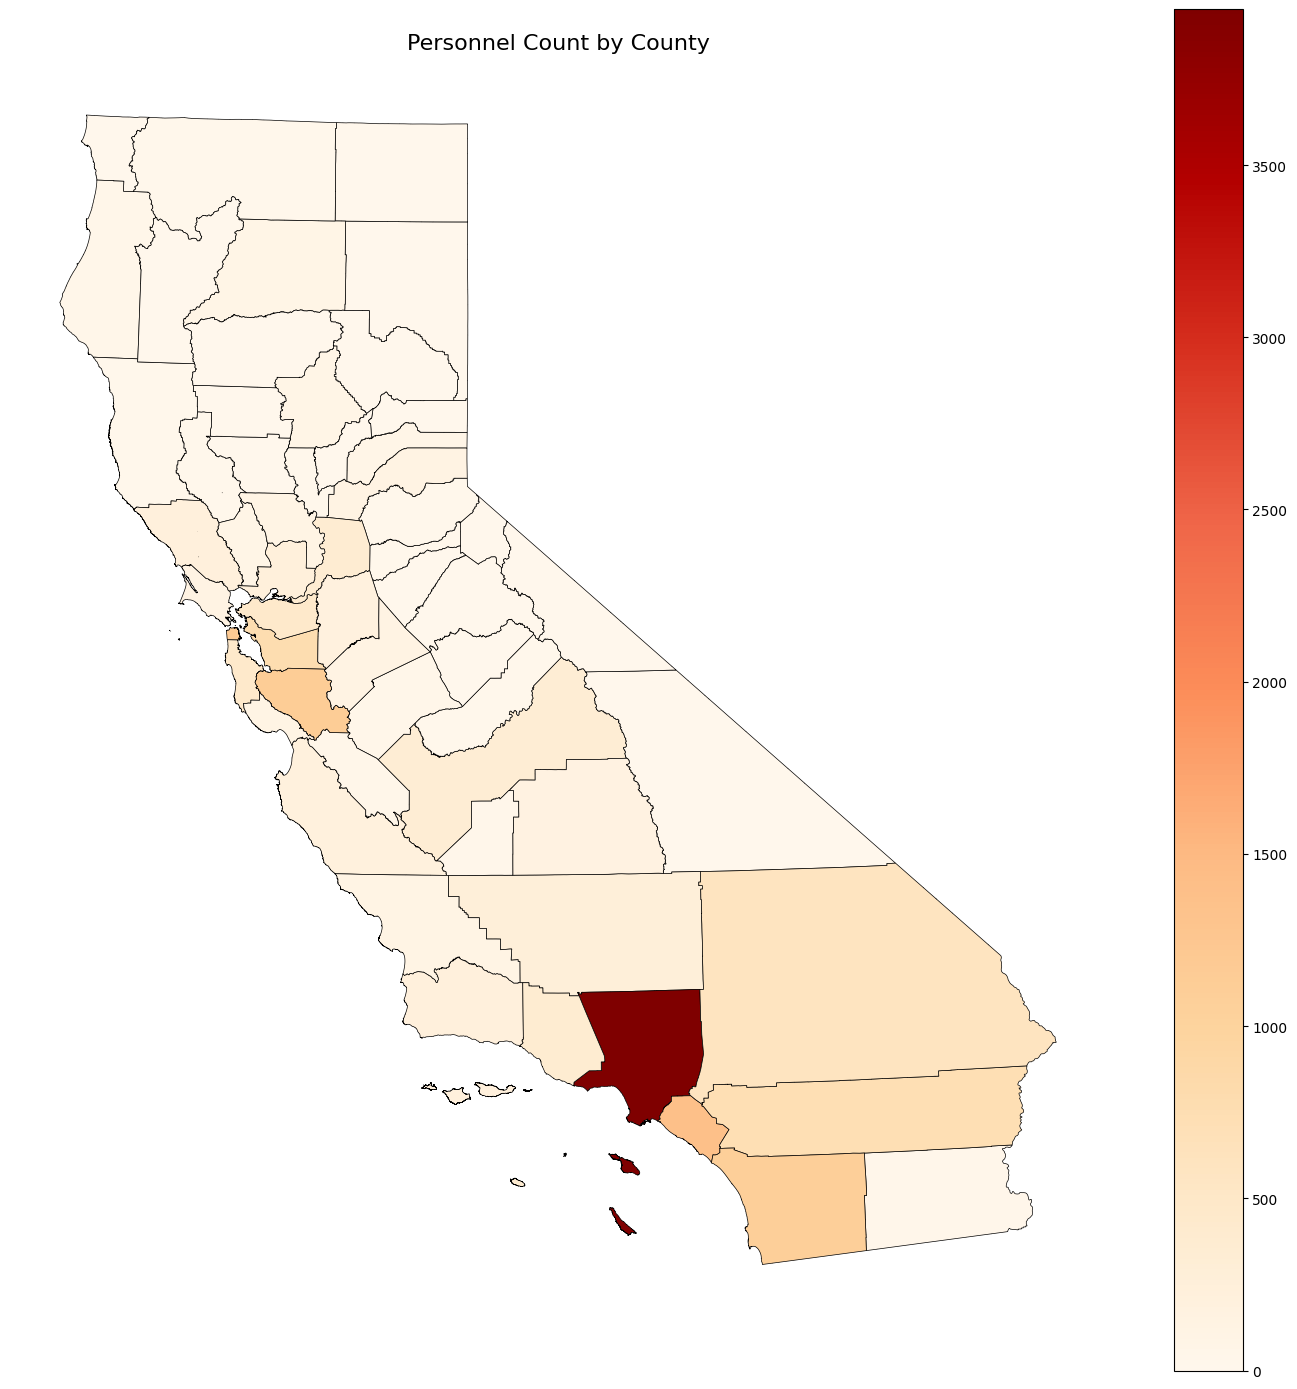

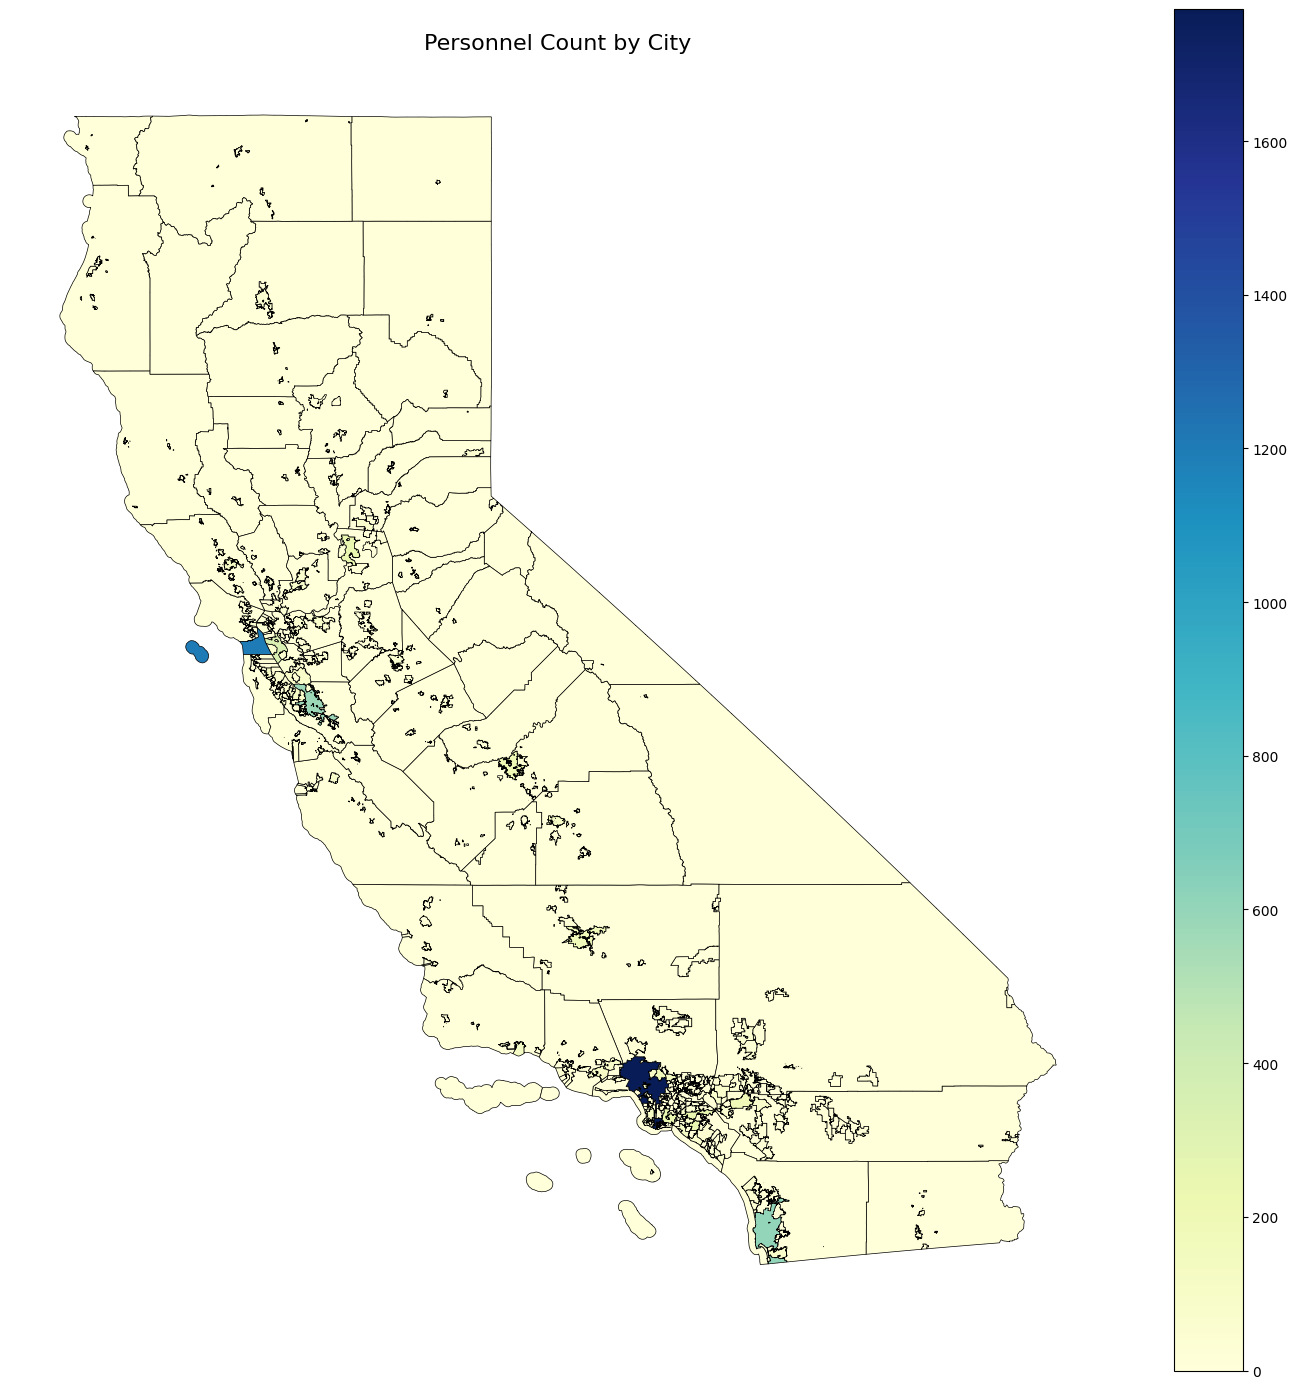

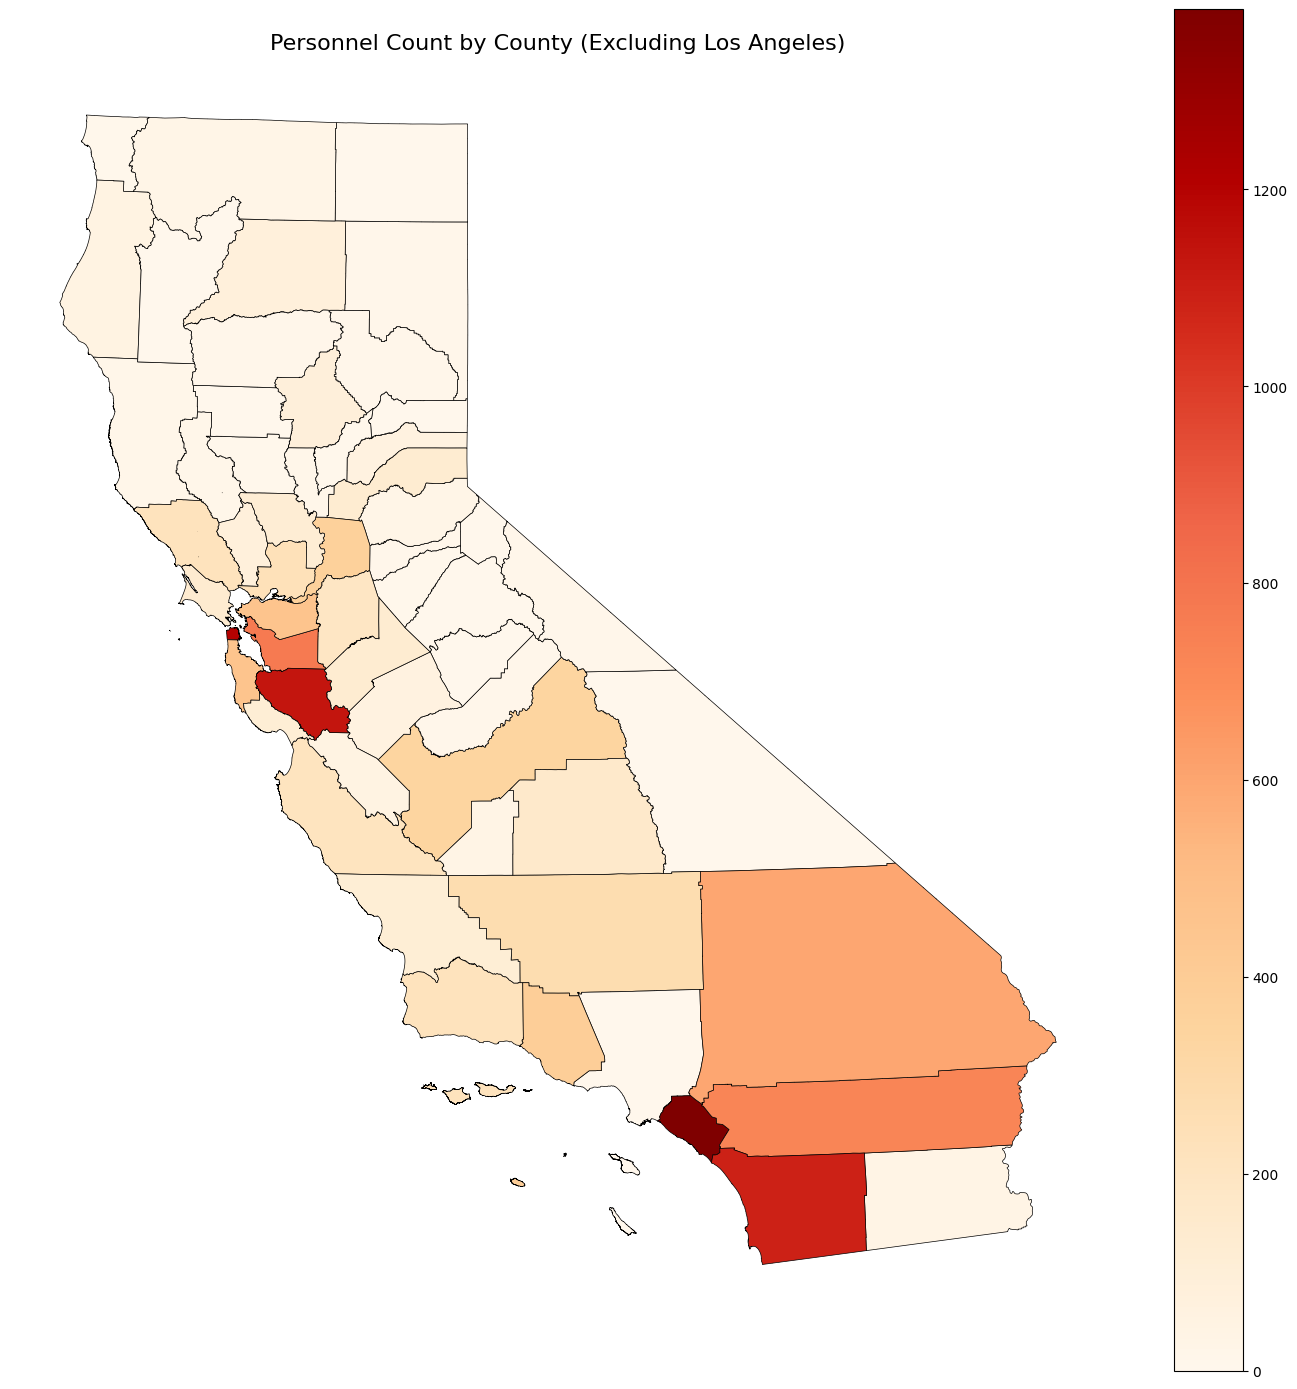

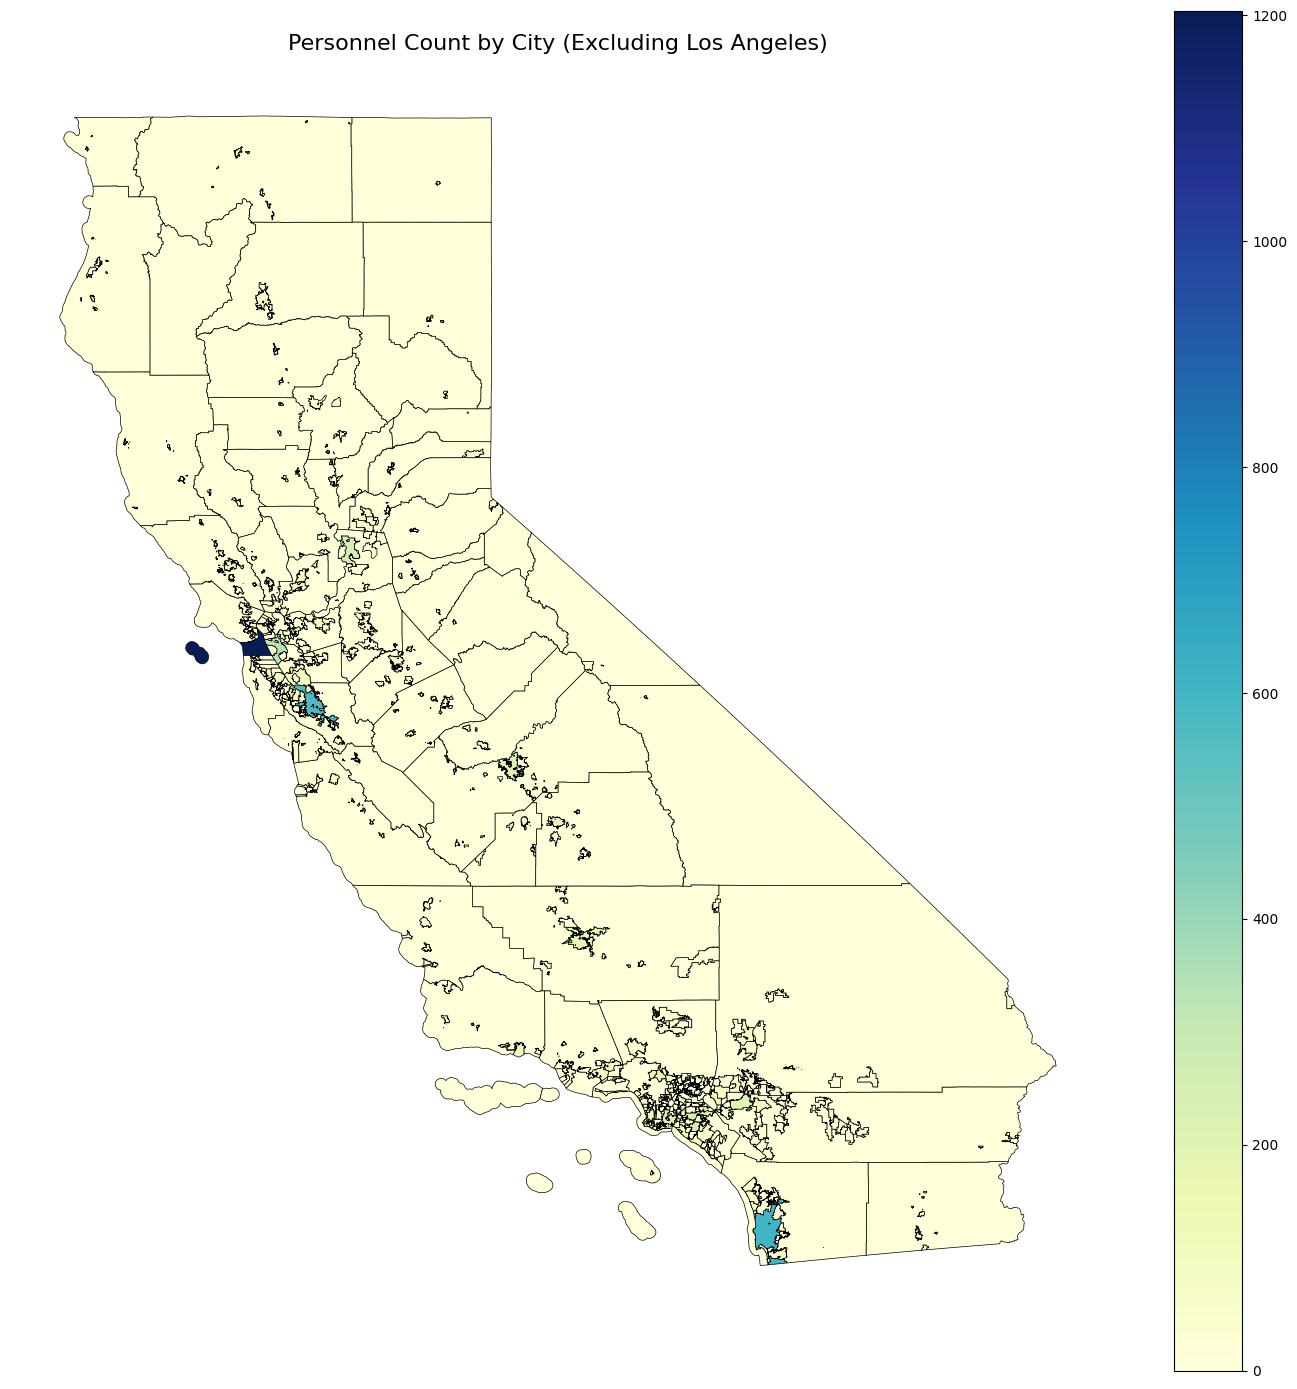

In [141]:
# Plot all maps

# County - All
plot_personnel_map(
    geo_county,
    column='personnel_count_county',
    title='Personnel Count by County',
    cmap='OrRd'
)

# City - All
plot_personnel_map(
    geo_city,
    column='personnel_count_city',
    title='Personnel Count by City',
    cmap='YlGnBu'
)

# County - Excluding Los Angeles
plot_personnel_map(
    geo_county_filtered,
    column='personnel_count_county',
    title = f"Personnel Count by County (Excluding {', '.join(excluded_counties)})",
    cmap='OrRd'
)

# City - Excluding Los Angeles
plot_personnel_map(
    geo_city_filtered,
    column='personnel_count_city',
    title = f"Personnel Count by City (Excluding {', '.join(excluded_cities)})",
    cmap='YlGnBu'
)



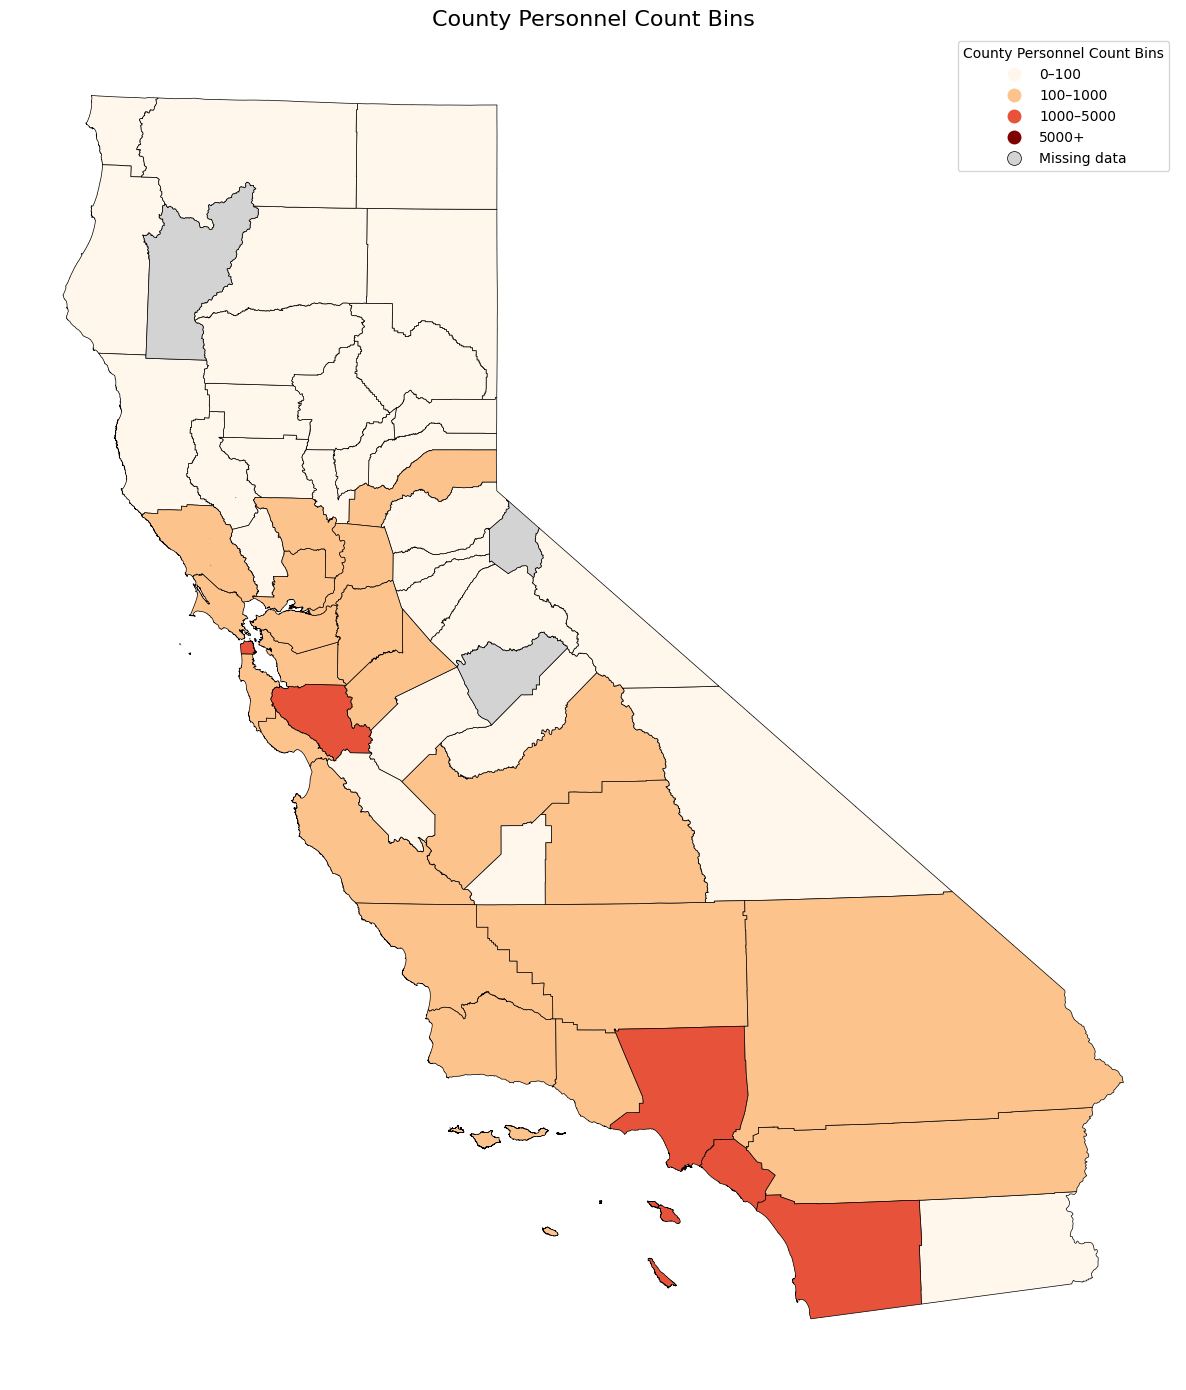

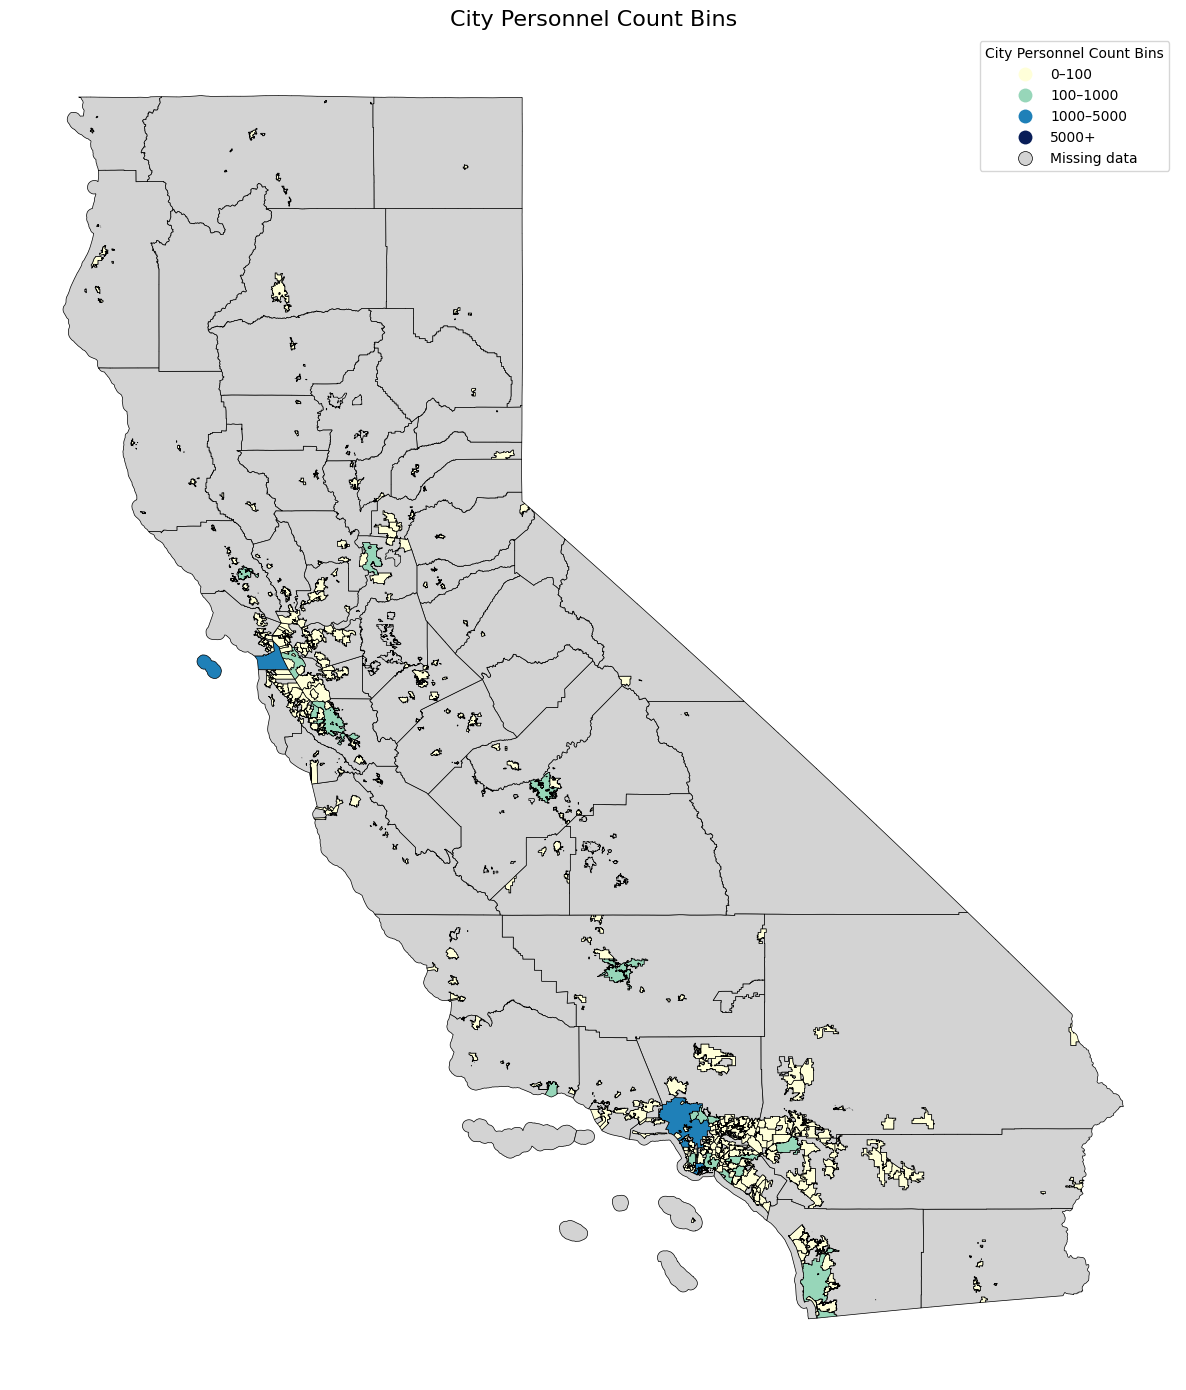

In [142]:
#  County Bins
plot_personnel_map(
    geo_county,
    column='county_personnel_bin',
    title='County Personnel Count Bins',
    cmap='OrRd'
)

#  City Bins
plot_personnel_map(
    geo_city,
    column='city_personnel_bin',
    title='City Personnel Count Bins',
    cmap='YlGnBu'
)

**<h3>General Statistics on Personnel Data Below**
* Dataframes: filtered_df, agg_city_counts, agg_county_counts,

In [ ]:
#filtered_df['DepartmentOrSubdivision'].value_counts().head(20)
filtered_df['Position'].value_counts().head(20).sum()



Position
Associate Planner                 364
Senior Planner                    293
Assistant Engineer                254
Assistant Planner                 241
Associate Engineer                236
Planning Commissioner             230
Building Inspector                201
Senior Civil Engineer             197
General Laborer                   157
Permit Technician                 154
Assistant Engineer - Civil        153
Building Mechanical Inspector     137
Building Inspector II             128
Principal Planner                 127
City Planner                      126
Code Enforcement Officer          125
Planning Assistant                119
Public Svc Aide-Public Works      113
Senior Building Inspector         112
Civil Engineering Associate II    108
Name: count, dtype: int64

In [ ]:
# Keywords to KEEP
keep_dept_keywords = [
    "Planning", "Community Development", "Building Department", "Code Compliance",
    "Public Works", "Streets", "Engineering", "Construction", "Zoning"
]

keep_position_keywords = [
    "Construction", "Building", "HVAC", "Plans Inspector", "Zoning Investigator",
    "Architect", "Permit Technician", "Safety Inspector", "Planner", "Code Enforcer",
    "Plan Check Coordinator", "Licensing Specialist", "Community Development Technician"
]

# Keywords to FILTER OUT
filter_dept_keywords = [
    "Administration", "Communications", "Animal", "Finance", "Community Services",
    "Municipal Power", "Base Reuse", "City Attorney", "City Clerk", "Council", "Fire",
    "Human Resources", "Library", "IT", "Police", "Recreation", "Government Services",
    "Facilities", "Water", "Power", "Airport", "Health", "Zero Waste", "Sewer",
    "Equipment", "Transfer Station", "Janitor", "Landscaping", "Utilities", "Business",
    "Transit", "Nutrition", "Aging", "Adult", "Youth", "Homeless", "Athletics", "Law",
    "Attorney", "Management","Public Works - Sanitation","Public Works - Street Services",
    "Public Works - Maint Svcs","Streets","Public Works-Operations","Public Works - Parks And Landscape ",
    "Public Works - Streets","Public Works-Corporate Yard","Public Works - Maintenance",
    "Public Works - Parks","Public Works Operations","Public Works - Refuse","Public Works/Solid Waste",
    "Public Works - Solid Waste","Public Works - Wastewater","Public Works/Street Maintenance",
    "War Memorial","Public Works - Right Of Way","Public Works - Utility Services", "Street Maintenance",
    "Public Works Parks","Grounds Maintenance","Public Works Yard",
    
]

filter_position_keywords = [
    "Motor Sweeper Operator","Public Works Ranger","Park Ranger","Administrative Assistant","Fitness instructor",
    "Administrative Intern","Equipment Operator","Crossing Guard","Park Lead","Plumber","Mechanic","Gardener",
    "Temporary","Chemist","Seasonal Aide","Plant Operator","Solid Resources","Parks","Asphalt Worker",
    "Business Analyst","Human Resources","Parking","Facilities","Golf","Downtown","Stationary","Groundskeeper"
    "Laboratory Technician", "Building & Grounds Patrol Officer", "Patrol Officer", "Youth Job Corps Program Participant",
    "School Guard","Tree Trimmer", "Transit Coach Operator", "Street Inspector","Utility Worker","Custodial",
    "Office Specialist","Street Services","Maintenance","Accountant","City Worker","Sanitation","Graffiti"
    "Maintenance Supervisor","Wastewater Treatment Operator","Wastewater Treatment Mechanic","Office Assistant",
    "Recreational Leader", "Librarian", "Admin", "Clerk","Wastewater System Operator","Water Foreman",
    "Wastewater Conveyance Operator","Management Assistant","Street Maintenance Worker","Maintenance Aide",
    "Lot Operator","Public Works Maintenance Worker","Maintenance Worker","Project Assistant","Project Manager",
    "Tree Surgeon","Intern","Truck Driver","Solid Waste Equipment Operator","Refuse Operator","Refuse Collection Supervisor",
    "Secretary", "Parking Officer", "Police", "Firefighter", "Treasurer", "Employment Worker",
    "Lifeguard", "Animal", "Recycling","Management Analyst", "Sewer", "Finance", "HR", "IT", "Parks & Rec",
    "Health", "EMT", "Custodian","Maintenance Worker", "Equipment Mechanic", "Aquatics", "Traffic",
    "Community Service", "Veterinary", "Senior Citizen", "Pool", "Utilities", "Audio","Irrigation Specialist",
    "Communications", "Mayor", "Attendant", "Vocational Worker", "Messenger Clerk","Staff Assistant",
    "Customer Service", "Truck Operator", "Sanitation", "Painter","Water Utility Worker","Arborist"
    "Laborer", "Program Assistant","Staff Specialist","Refuse","Department Assistant","Landscape"
]


In [145]:
# Most workers per city
city_counts = filtered_df['clean_city_name'].value_counts()
print("Top 10 Cities by Worker Count:\n", city_counts.head(10))

# Least workers (but drop NaNs first)
print("\nBottom 10 Cities by Worker Count:\n", city_counts[city_counts > 0].tail(10))
print("\nNAs:\n", city_counts.isna().sum())


Top 10 Cities by Worker Count:
 clean_city_name
Los Angeles      1772
San Francisco    1204
San Diego         604
San Jose          576
Oakland           338
Santa Ana         251
Anaheim           249
Sacramento        244
Long Beach        236
Fresno            203
Name: count, dtype: int64

Bottom 10 Cities by Worker Count:
 clean_city_name
Gridley          1
Gustine          1
Rolling Hills    1
Colusa           1
Lindsay          1
Ione             1
San Joaquin      1
Maricopa         1
Calimesa         1
Canyon Lake      1
Name: count, dtype: int64

NAs:
 0


In [34]:
# Most workers per county
county_counts = filtered_df['clean_county_name'].value_counts()
print("Top 10 Counties by Worker Count:\n", county_counts.head(10))

# Least workers
print("\nBottom 10 Counties by Worker Count:\n", county_counts[county_counts > 0].tail(10))
print("\nNAs:\n", county_counts.isna().sum())


Top 10 Counties by Worker Count:
 clean_county_name
Los Angeles       8220
Orange            2277
San Diego         1622
Santa Clara       1574
San Francisco     1278
Alameda           1222
Riverside         1169
Contra Costa       962
San Bernardino     948
San Mateo          748
Name: count, dtype: int64

Bottom 10 Counties by Worker Count:
 clean_county_name
Del Norte    25
Lassen       24
Colusa       20
Yuba         19
Glenn        14
Plumas       12
Modoc        10
Calaveras     7
Sierra        6
Tuolumne      6
Name: count, dtype: int64

NAs:
 0


In [43]:
g = 10  # Change as needed

# Cities with < g positions
cities_under_g = city_counts[city_counts < g]
print(f"\nNumber of cities with fewer than {g} positions: {len(cities_under_g)}")
print(cities_under_g.head(10))



Number of cities with fewer than 10 positions: 92
clean_city_name
Laguna Hills     9
Wildomar         9
Pleasant Hill    9
Azusa            9
Corcoran         9
Cerritos         9
Live Oak         9
Exeter           9
Jackson          9
Solvang          9
Name: count, dtype: int64


In [45]:
b = 25 # Change as needed

# Counties with < b positions
counties_under_b = county_counts[county_counts < b]
print(f"\nNumber of counties with fewer than {b} positions: {len(counties_under_b)}")
print(counties_under_b.head(10))


Number of counties with fewer than 25 positions: 9
clean_county_name
Lassen       24
Colusa       20
Yuba         19
Glenn        14
Plumas       12
Modoc        10
Calaveras     7
Sierra        6
Tuolumne      6
Name: count, dtype: int64


In [46]:
# Missing city name
missing_city = filtered_df['clean_city_name'].isna().sum()
print(f"Rows with missing city name: {missing_city}")

# Missing county name
missing_county = filtered_df['clean_county_name'].isna().sum()
print(f"Rows with missing county name: {missing_county}")

# Optionally: View rows
filtered_df[filtered_df['clean_city_name'].isna() | filtered_df['clean_county_name'].isna()]


Rows with missing city name: 0
Rows with missing county name: 0


,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,MaxPositionSalary,...,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType,combined_text,predicted_label,clean_city_name,clean_county_name


In [ ]:
filtered_df['DepartmentOrSubdivision'].value_counts().head(10)


DepartmentOrSubdivision
Public Works                      10427
Community Development              2382
Public Works - Sanitation          1475
Public Works - Engineering          793
Public Works - Street Services      787
Planning                            709
City Planning                       681
Public Works Department             545
Engineering & Capital Projects      530
Engineering                         506
Name: count, dtype: int64

In [51]:
filtered_df.groupby('clean_city_name')['Position'].nunique().sort_values(ascending=False).head(10)


clean_city_name
Los Angeles      368
San Francisco    157
Oakland          137
Anaheim          126
Long Beach       122
Santa Ana        122
San Jose         118
Riverside        111
Glendale         108
Santa Barbara    100
Name: Position, dtype: int64

In [25]:
# View Distributions
print("City Personnel Bins Distribution")
print(agg_city_counts['city_personnel_bin'].value_counts().sort_index())

print("County Personnel Bin Distribution")
print(agg_county_counts['county_personnel_bin'].value_counts().sort_index())

City Personnel Bins Distribution
city_personnel_bin
0–100        419
100–1000      54
1000–5000      2
5000+          0
Name: count, dtype: int64
County Personnel Bin Distribution
county_personnel_bin
0–100        22
100–1000     25
1000–5000     6
5000+         1
Name: count, dtype: int64
